In [1]:
#!pip install git+https://github.com/lsst-sims/rubin_nights.git --no-deps

import os
import copy

import numpy as np
import healpy as hp
import datetime

import pandas as pd
from pandas import option_context
from IPython.display import display, Markdown, HTML

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker 

from astropy.time import Time, TimeDelta
import astropy.units as u
from rubin_scheduler.utils import Site
from astropy.coordinates import SkyCoord, AltAz
from astroplan import Observer
from rubin_scheduler.utils import pseudo_parallactic_angle, approx_ra_dec2_alt_az, approx_altaz2pa, rotation_converter
from rubin_scheduler.utils import angular_separation

import astropy
astropy.utils.iers.conf.iers_degraded_accuracy = 'ignore'

from rubin_nights import connections
import rubin_nights.rubin_sim_addons as rn_sim
import rubin_nights.rubin_scheduler_addons as rn_sch
import rubin_nights.dayobs_utils as rn_dayobs
import rubin_nights.observatory_status as rn_observatory

os.environ["RUBIN_SIM_DATA_DIR"] = "/sdf/data/rubin/shared/rubin_sim_data"

from rubin_scheduler.scheduler.model_observatory import KinemModel, tma_movement, rotator_movement

from lsst.summit.utils.tmaUtils import TMAEventMaker, TMAState

In [2]:
# Choose a day range to get information - will narrow it down to actual visit time below
t_start = Time('2025-07-01T12:00:00')
t_end = Time('2025-07-10T12:00:00')

day_obs_start = int(t_start.iso[0:10].replace('-', ''))
day_obs_end = int(t_end.iso[0:10].replace('-', '')) 

endpoints = connections.get_clients()
print(t_start.utc.iso, t_end.utc.iso)

2025-07-01 12:00:00.000 2025-07-10 12:00:00.000


In [3]:
# Get all of the TMA speed limits 
tma = rn_observatory.get_tma_limits(t_start, t_end, endpoints['efd'])

In [4]:
# Get Visit Information. 
visits = endpoints['consdb'].get_visits("lsstcam", t_start, t_end)

print(len(visits))

7336


In [5]:
tma_movement(1)

{'azimuth_maxspeed': np.float64(0.1),
 'azimuth_accel': 0.1,
 'azimuth_jerk': np.float64(1.0),
 'altitude_maxspeed': 0.05,
 'altitude_accel': 0.05,
 'altitude_jerk': np.float64(1.0),
 'settle_time': 3.0}

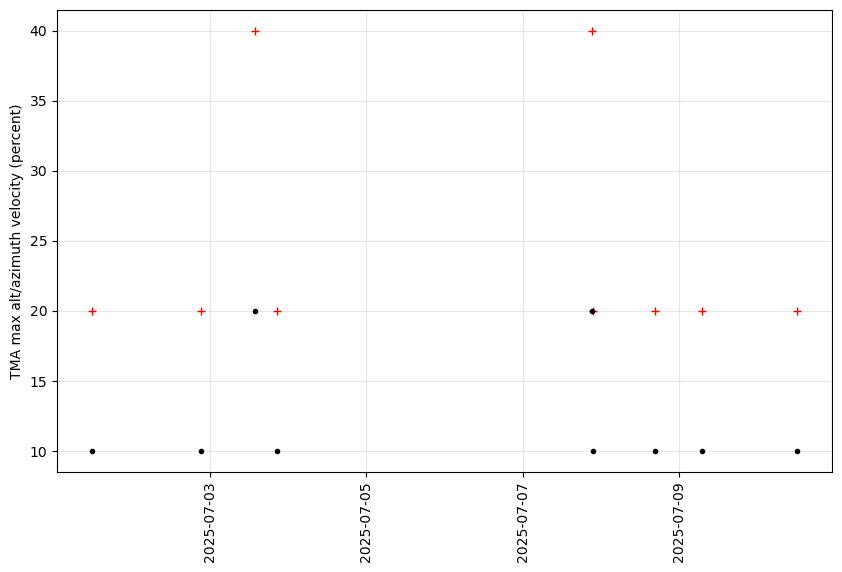

In [6]:
# Show TMA speeds tested at different times
one_percent_speed = tma_movement(1)
plt.figure(figsize=(10, 6))
plt.plot(tma.index.values, tma.altitude_maxspeed/one_percent_speed['altitude_maxspeed'], 'r+')
plt.plot(tma.index.values, tma.azimuth_maxspeed/one_percent_speed['azimuth_maxspeed'], 'k.')
plt.tick_params("x", rotation=90)
plt.ylabel("TMA max alt/azimuth velocity (percent)")
ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(2)) 
plt.grid(alpha=0.3)
# list(zip(tma.index, tma['azimuth_maxspeed']/maxval['azimuth_maxspeed']))

In [7]:
one_day = TimeDelta(1, format='jd')
days = t_start + one_day * np.arange(0, (t_end - t_start).jd + 0.5)
day_obs_list = [d.iso[0:10] for d in days]

In [8]:
async def get_tma_event_times(day_obs_list, visits):
    # TMA Event Maker
    eventMaker = TMAEventMaker()

    tma_slews = {}
    tma_tracks = {}
    tma_slewids = {}
    n_tmaevents = {}
    n_tmafaults = {}
    n_tmastops = {}
    image_tracking = {}
    wait_time_after = {}
    wait_time_before = {}
    
    for dayobs in day_obs_list:
        day = int(dayobs.replace('-', ''))
        night_visits = visits.query('day_obs == @day').sort_values(by='seq_num')
        events = eventMaker.getEvents(day, addBlockInfo=False) 
        if len(night_visits) > 0:
            for i, s in night_visits.iterrows():
                slewtime = 0
                tracktime = 0
                wa = 100000
                wb = 100000
                nevents = 0
                n_stops = 0
                n_faults = 0
                slewids = []
                image_tracking[i] = False
                for e in events:
                    if e.begin.tai.mjd > s.prev_obs_end_mjd and e.end.tai.mjd < s.obs_start_mjd:
                        if e.type == TMAState.SLEWING:                        
                            # There could be more than one slew event between visits
                            nevents += 1
                            slewids.append(e.seqNum)
                            slewtime += e.duration
                            dt = (e.begin.tai.mjd - s.prev_obs_end_mjd) * 24 * 60 * 60
                            wb = np.min([dt, wb])
                            dt = (s.obs_start_mjd - e.end.tai.mjd) * 24 * 60 * 60
                            wa = np.min([dt, wa])
                        if e.endReason == TMAState.STOPPED:
                            n_stops += 1
                        if e.endReason == TMAState.FAULT:
                            n_faults += 1
                    if e.begin.tai.mjd <= s.obs_start_mjd and e.end.tai.mjd >= s.obs_end_mjd:
                        if e.type == TMAState.TRACKING:
                            tracktime += e.duration
                            image_tracking[i]= True
                tma_slews[i] = slewtime
                tma_slewids[i] = slewids
                n_tmaevents[i] = nevents
                n_tmafaults[i] = n_faults
                n_tmastops[i] = n_stops
                tma_tracks[i] = tracktime
                wait_time_after[i] = wa
                wait_time_before[i] = wb

    slewing = pd.DataFrame([tma_slewids, tma_slews, tma_tracks, wait_time_before, wait_time_after, n_tmaevents, n_tmafaults, n_tmastops, image_tracking], 
               index=['TMAseqnums', 'TMAslew', 'TMAtrack', 'waitBeforeSlew', 'waitAfterSlew', 'nTMAslews', 'nTMAfaults', 'nTMAstops', 'image_tracking']).T
    return slewing

In [9]:
# Add the TMA slews to the model information
tracking = await get_tma_event_times(day_obs_list[0:-1], visits)
visitT = visits.merge(tracking, right_index=True, left_index=True)
print(len(visitT), len(tracking))

7336 7336


In [10]:
# Add model slewtimes and mtm1m3 slews 

# Use the full visits to check slew times 
# wait_before_slew comes from looking at TMAevent slews
wait_before_slew = 0
settle = 1.0
visitsS, slewing = rn_sch.add_model_slew_times(visits, endpoints['efd'], model_settle=wait_before_slew + settle, dome_crawl=True)
mt_slews = []
for day_obs in day_obs_list:
    sunset, sunrise = rn_dayobs.day_obs_sunset_sunrise(day_obs, -10)
    try:
        mt_slews.append(rn_observatory.mtm1m3_slewflag_times(sunset, sunrise, endpoints['efd']))
    except:
        print(f"no slews day_obs {day_obs}")
        pass
mt_slews = pd.concat(mt_slews)
mt_slews['mt_slew_time'] += wait_before_slew
visitsS = visitsS.merge(mt_slews, how='left', left_on='group_id', right_on='groupId')

In [11]:
vts = visitsS.merge(visitT[['visit_id'] + [c for c in tracking.columns]], how='left', right_on='visit_id', left_on='visit_id')
vts['science_program'].unique()

array(['BLOCK-T454', 'BLOCK-T551', 'BLOCK-T539', 'BLOCK-365', 'unknown',
       'BLOCK-T399', 'BLOCK-T553', 'BLOCK-T554', 'BLOCK-T555',
       'BLOCK_T339_none', 'BLOCK-T250', 'BLOCK-T339', 'BLOCK_T339_g',
       'BLOCK-T556_1', 'BLOCK-T556_2', 'BLOCK-T556_3', 'BLOCK-T556_4',
       'BLOCK-T556_5', 'BLOCK-T511_1', 'BLOCK-R308', 'BLOCK-E8024',
       'BLOCK-T559', 'E8139', 'E8128'], dtype=object)

In [12]:
vts[vts['mt_slew_time'].isna()].query("img_type == 'science'")[['visit_id', 'img_type', 'observation_reason', 'science_program', 'slew_model', 'TMAslew', 'mt_slew_time', 'scriptSalIndex']]

,visit_id,img_type,observation_reason,science_program,slew_model,TMAslew,mt_slew_time,scriptSalIndex
59,2025070100126,science,field_survey_science,BLOCK-365,10.131712,7.172843,NaN,110177.0
124,2025070100191,science,triplet_pairs_iz_33.0,BLOCK-365,5.400810,358.621334,NaN,110248.0
1238,2025070200510,science,template_blob_r_33.0,BLOCK-365,3.070000,0,NaN,111213.0
1239,2025070200511,science,template_blob_r_33.0,BLOCK-365,22.592673,23.708151,NaN,111214.0
1710,2025070300356,science,template_blob_z_33.0,BLOCK-365,9.381438,11.685496,NaN,111617.0
2390,2025070400291,science,pairs_yy_33.0,BLOCK-365,5.195967,14.485304,NaN,112383.0
5807,2025070800108,science,pairs_iz_33.0,BLOCK-365,13.789450,350.190621,NaN,114892.0
6108,2025070800410,science,pairs_yy_33.0,BLOCK-365,8.441450,94.051595,NaN,115192.0


1.4838049421086907
0.8492463617585599


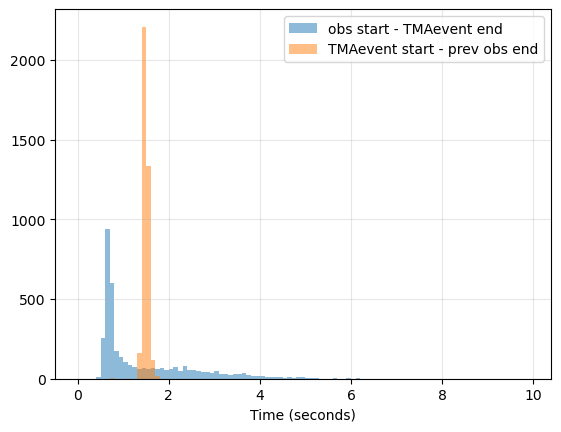

In [13]:
programs = ["BLOCK-365", "BLOCK-407", "BLOCK-408", "BLOCK-416", "BLOCK-417", "BLOCK-419", "BLOCK-421"]
q = vts.query("science_program in @programs")
_ = plt.hist(q.waitAfterSlew, bins=np.arange(0, 10, 0.1), alpha=0.5, label="obs start - TMAevent end")
_ = plt.hist(q.waitBeforeSlew, bins=np.arange(0, 10, 0.1), alpha=0.5, label="TMAevent start - prev obs end")
plt.legend()
plt.xlabel("Time (seconds)")
plt.grid(alpha=0.3)
print(vts.query("science_program in @programs and waitBeforeSlew < 10").waitBeforeSlew.median())
print(vts.query("science_program in @programs and waitAfterSlew < 10").waitAfterSlew.median())

In [14]:
cols = ['day_obs', 'visit_id', 'band', 's_dec', 'waitBeforeSlew', 'waitAfterSlew', 'nTMAslews', 'nTMAstops', 'target_name', 'observation_reason']
#q.query("day_obs == 20260523 and waitAfterSlew> 4 and waitAfterSlew < 10 and waitBeforeSlew<60")[cols]

(1.0, 6.0)

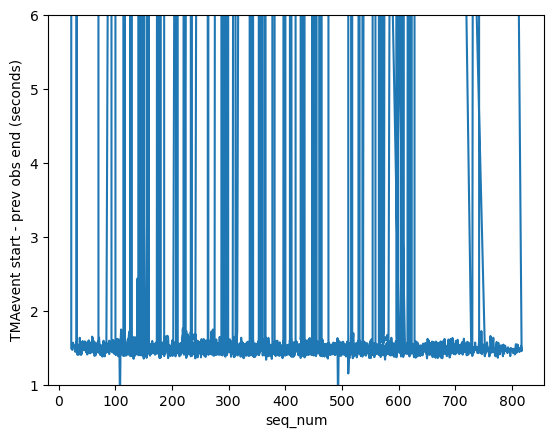

In [15]:
q = vts.query("science_program in @programs")
plt.plot(q.seq_num, q.waitBeforeSlew)
plt.xlabel("seq_num")
plt.ylabel("TMAevent start - prev obs end (seconds)")
plt.ylim(1, 6)

Text(0, 0.5, 'Seconds')

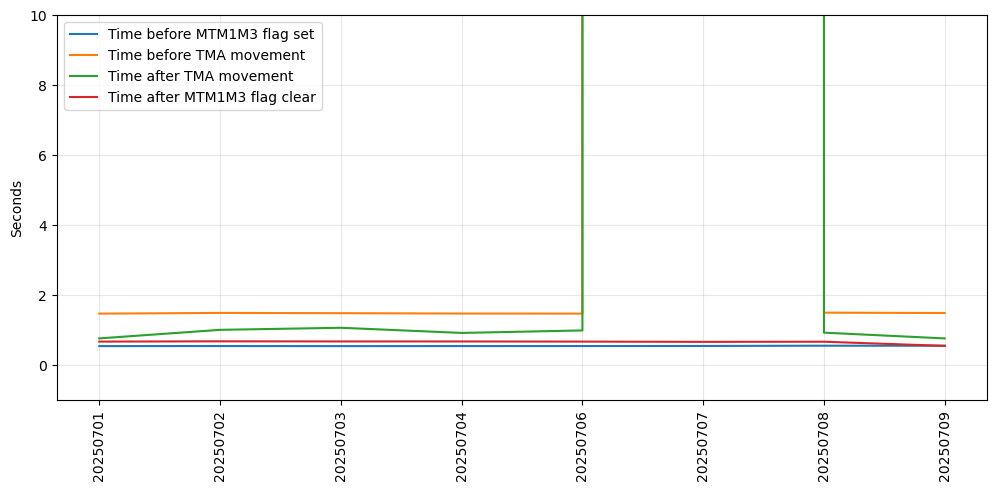

In [17]:
q = vts.query("science_program in @programs").copy()
q['mtStart'] = ((Time(q.mtm1m3_set.values).utc - Time(q.prev_obs_end_mjd.values, format='mjd', scale='tai').utc).jd * 24 * 60 * 60)
q['mtEnd'] = ((Time(q.obs_start_mjd.values, format='mjd', scale='tai').utc - Time(q.mtm1m3_clear.values).utc).jd * 24 * 60 * 60)
qq = q.groupby("day_obs").agg({"waitAfterSlew": "median", "waitBeforeSlew": "median", 'mtStart': 'median', "mtEnd": "median"})
#qq = q.groupby("day_obs").agg({"waitAfterSlew": "mean", "waitBeforeSlew": "mean", 'mtStart': "mean", "mtEnd": "mean"})
x = np.arange(len(qq))
plt.figure(figsize=(12, 5))
plt.plot(x, qq.mtStart, label='Time before MTM1M3 flag set')
plt.plot(x, qq.waitBeforeSlew, label='Time before TMA movement')
plt.plot(x, qq.waitAfterSlew, label='Time after TMA movement')
plt.plot(x, qq.mtEnd, label='Time after MTM1M3 flag clear')
_ = plt.xticks(x, qq.index, rotation=90)
plt.ylim(-1, 10)
plt.grid(alpha=0.3)
plt.legend(loc='upper left')
plt.ylabel("Seconds")

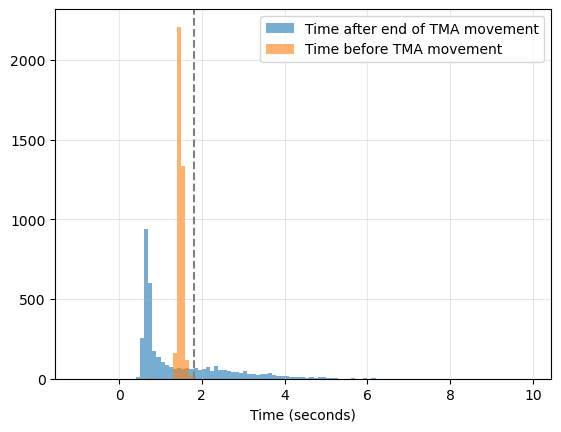

In [18]:
q = vts.query("science_program in @programs")
_ = plt.hist(q.waitAfterSlew, bins=np.arange(-1, 10.0, 0.1), alpha=0.6, label="Time after end of TMA movement")
_ = plt.hist(q.waitBeforeSlew, bins=np.arange(-1, 10.0, 0.1),alpha=0.6, label="Time before TMA movement",)
plt.axvline(0.9 + 0.9, color='gray', linestyle='--')
plt.legend()
plt.xlabel("Time (seconds)")
plt.grid(alpha=0.3)

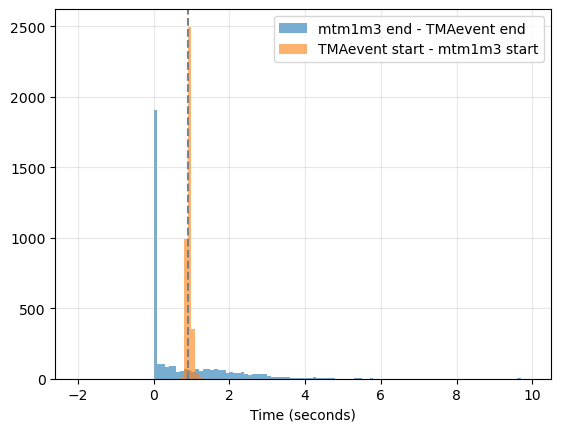

In [19]:
q = vts.query("mt_slew_time > 0 and science_program in @programs")
_ = plt.hist(q.waitAfterSlew - (q.obs_start_mjd - Time(q.mtm1m3_clear, scale='utc').tai.mjd)*24*60*60, bins=np.arange(-2, 10.0, 0.1), alpha=0.6, label="mtm1m3 end - TMAevent end ")
_ = plt.hist(q.waitBeforeSlew - (Time(q.mtm1m3_set, scale='utc').tai.mjd - q.prev_obs_end_mjd)*24*60*60, bins=np.arange(-2, 10.0, 0.1), alpha=0.6, label="TMAevent start - mtm1m3 start",)
plt.axvline(0.9, color='gray', linestyle='--')
plt.legend()
plt.xlabel("Time (seconds)")
plt.grid(alpha=0.3)

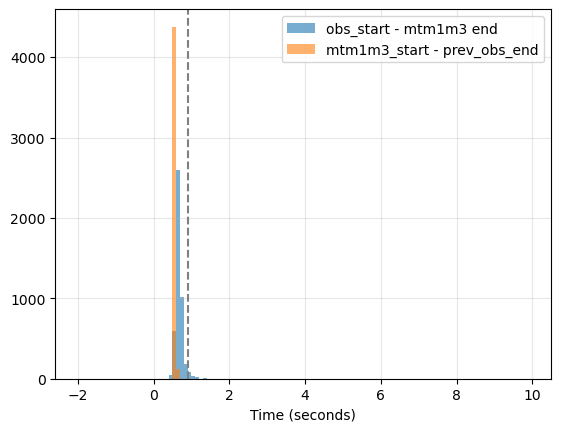

In [20]:
q = vts.query("mt_slew_time > 0 and science_program in @programs")
_ = plt.hist((q.obs_start_mjd - Time(q.mtm1m3_clear, scale='utc').tai.mjd)*24*60*60, bins=np.arange(-2, 10.0, 0.1), alpha=0.6, label="obs_start - mtm1m3 end")
_ = plt.hist((Time(q.mtm1m3_set, scale='utc').tai.mjd - q.prev_obs_end_mjd)*24*60*60, bins=np.arange(-2, 10.0, 0.1), alpha=0.6, label="mtm1m3_start - prev_obs_end",)
plt.axvline(0.9, color='gray', linestyle='--')
plt.legend()
plt.xlabel("Time (seconds)")
plt.grid(alpha=0.3)

Text(0.5, 0, 'Time (seconds)')

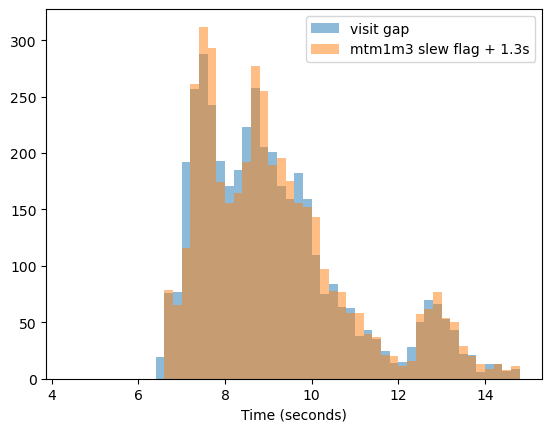

In [22]:
q = vts.query("mt_slew_time > 0")
_ = plt.hist(q.visit_gap, bins=np.arange(4.4, 15, 0.2), alpha=0.5, label="visit gap")
extra = 1.3
_ = plt.hist(q.mt_slew_time+extra, bins=np.arange(4.4, 15, 0.2), alpha=0.5, label=f"mtm1m3 slew flag + {extra:.1f}s")
plt.legend()
plt.xlabel("Time (seconds)")

In [23]:
print(q.day_obs.min(), q.day_obs.max())
q.science_program.unique()

20250701 20250709


array(['BLOCK-365'], dtype=object)

['triplet_pairs_iz_33.0' 'template_blob_z_33.0' 'pairs_iz_33.0'
 'template_blob_r_33.0' 'template_blob_i_33.0' 'pairs_ri_15.0'
 'ddf_elaiss1' 'pairs_gr_33.0' 'pairs_zy_33.0' 'template_blob_y_33.0'
 'pairs_yy_33.0' 'too' 'template_area_singles_i' 'singles_i'
 'pairs_ri_33.0' 'pairs_zy_15.0']


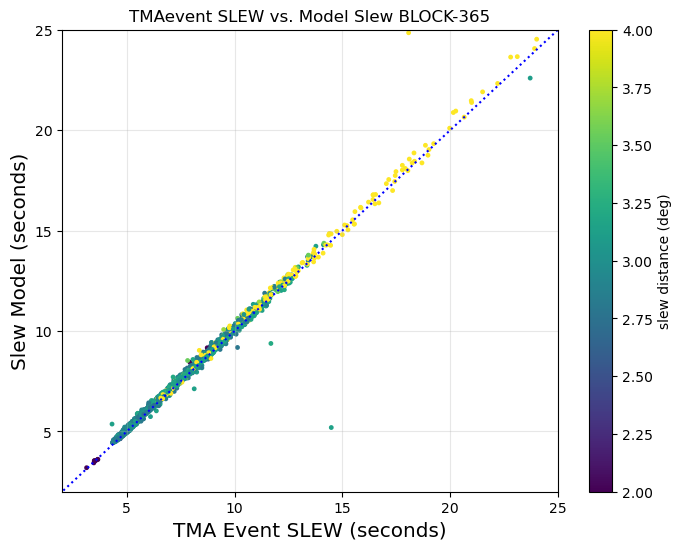

In [49]:
plt.figure(figsize=(8, 6))
# Pull up slews *within* a given science_program 
within_program = np.where(vts.iloc[:-1].science_program.values == vts.iloc[1:].science_program.values)[0]
q = vts.iloc[within_program + 1]
program = "BLOCK-365"

q = q.query("science_program == @program and observation_reason != 'field_survey_science' and observation_reason != 'block-t548' ")
print(q.observation_reason.unique())
plt.scatter(q.TMAslew, q.slew_model, 
            c=q.slew_distance, vmin=2, vmax=4,
            s=6)
plt.colorbar(label='slew distance (deg)')
x = np.arange(0, 100)
plt.plot(x, x, 'b:')
plt.xlim(4, 20)
plt.ylim(4, 20)
plt.xlim(2, 25)
plt.ylim(2, 25)
#plt.xlabel("Visit gap (seconds)", fontsize='x-large')
plt.ylabel("Slew Model (seconds)", fontsize='x-large')
plt.xlabel("TMA Event SLEW (seconds)", fontsize='x-large')
plt.grid(alpha=0.3)
plt.title(f"TMAevent SLEW vs. Model Slew {program}", fontsize='large')
#plt.title(f"TMAevent SLEW vs. visit gap (BLOCK-365)", fontsize='large')
plt.savefig('SlewModelVsTMA.pdf')

# I am wondering if at least some of this scatter is the rotator, and then some of the TMA being quicker than the slew model for longer slews is the dome.

In [50]:
q.query("TMAslew < 10 and slew_model>25")

,visit_id,exposure_name,controller,day_obs,seq_num,physical_filter,band,s_ra,s_dec,sky_rotation,...,mt_slew_time,TMAseqnums,TMAslew,TMAtrack,waitBeforeSlew,waitAfterSlew,nTMAslews,nTMAfaults,nTMAstops,image_tracking
154,2025070100221,MC_O_20250701_000221,O,20250701,221,z_20,z,267.219898,-30.933323,127.020123,...,145.536788,"[235, 237, 238, 240]",7.478937,48.729591,1.549979,16.30365,4,0,1,True
286,2025070100353,MC_O_20250701_000353,O,20250701,353,i_39,i,266.279748,-16.411247,106.523933,...,140.828584,"[504, 506, 507, 509]",7.894227,146.586254,1.529061,15.465547,4,0,1,True
656,2025070100723,MC_O_20250701_000723,O,20250701,723,r_57,r,344.707830,-0.935442,78.700340,...,132.302992,"[1247, 1249, 1250, 1252]",9.917335,48.521575,1.571067,16.139666,4,0,1,True
997,2025070200269,MC_O_20250702_000269,O,20250702,269,i_39,i,266.646902,-16.196114,116.365463,...,35.113207,[247],6.754138,60.526219,1.719056,27.883386,1,0,0,True
999,2025070200271,MC_O_20250702_000271,O,20250702,271,z_20,z,263.758322,-17.279729,116.135688,...,117.293468,"[251, 253, 254, 256]",8.96524,33.321998,1.535034,0.644837,4,0,1,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6814,2025070900468,MC_O_20250709_000468,O,20250709,468,i_39,i,9.302714,-43.860342,143.601144,...,137.557712,"[960, 961, 963]",2.411498,170.149132,15.278172,11.182956,3,0,1,True
6818,2025070900472,MC_O_20250709_000472,O,20250709,472,y_10,y,9.302792,-43.860340,143.600677,...,129.020611,"[965, 966, 968]",2.307275,160.45925,15.496222,11.616755,3,0,1,True
6930,2025070900584,MC_O_20250709_000584,O,20250709,584,z_20,z,340.694050,-9.210451,155.609258,...,136.164830,"[1196, 1198, 1199, 1201]",9.210454,43.695247,1.471893,11.332863,4,0,1,True
6993,2025070900647,MC_O_20250709_000647,O,20250709,647,i_39,i,346.426243,4.419080,147.094079,...,151.349901,"[1327, 1329, 1330, 1332]",7.990226,46.33017,1.485413,13.942574,4,0,1,True


4255 ['triplet_pairs_iz_33.0' 'template_blob_z_33.0' 'pairs_iz_33.0'
 'template_blob_r_33.0' 'template_blob_i_33.0' 'pairs_ri_15.0'
 'ddf_elaiss1' 'pairs_gr_33.0' 'pairs_zy_33.0' 'template_blob_y_33.0'
 'pairs_yy_33.0' 'too' 'template_area_singles_i' 'singles_i'
 'pairs_ri_33.0' 'pairs_zy_15.0']


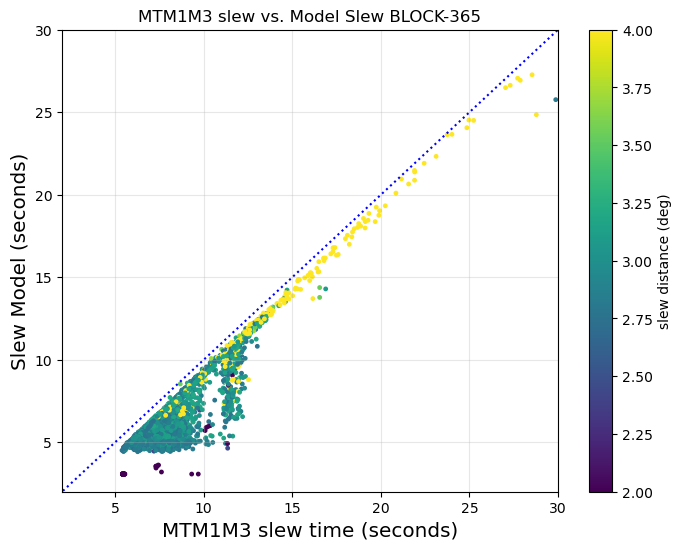

In [51]:
plt.figure(figsize=(8, 6))
# Pull up slews *within* a given science_program 
within_program = np.where(vts.iloc[:-1].science_program.values == vts.iloc[1:].science_program.values)[0]
q = vts.iloc[within_program + 1]

q = q.query("science_program == @program and observation_reason != 'field_survey_science' and observation_reason != 'block-t548' ")
print(len(q), q.observation_reason.unique())
plt.scatter(q.mt_slew_time, q.slew_model, 
            c=q.slew_distance, vmin=2, vmax=4,
            s=6)
plt.colorbar(label='slew distance (deg)')
x = np.arange(0, 100)
plt.plot(x, x, 'b:')
plt.xlim(4, 20)
plt.ylim(4, 20)
plt.xlim(2, 30)
plt.ylim(2, 30)
#plt.xlabel("Visit gap (seconds)", fontsize='x-large')
plt.ylabel("Slew Model (seconds)", fontsize='x-large')
plt.xlabel("MTM1M3 slew time (seconds)", fontsize='x-large')
plt.grid(alpha=0.3)
plt.title(f"MTM1M3 slew vs. Model Slew {program}", fontsize='large')
#plt.title(f"TMAevent SLEW vs. visit gap (BLOCK-365)", fontsize='large')
plt.savefig('SlewModelVsMTM1M3.png')

# where does this scatter come from? 

4255 ['triplet_pairs_iz_33.0' 'template_blob_z_33.0' 'pairs_iz_33.0'
 'template_blob_r_33.0' 'template_blob_i_33.0' 'pairs_ri_15.0'
 'ddf_elaiss1' 'pairs_gr_33.0' 'pairs_zy_33.0' 'template_blob_y_33.0'
 'pairs_yy_33.0' 'too' 'template_area_singles_i' 'singles_i'
 'pairs_ri_33.0' 'pairs_zy_15.0']


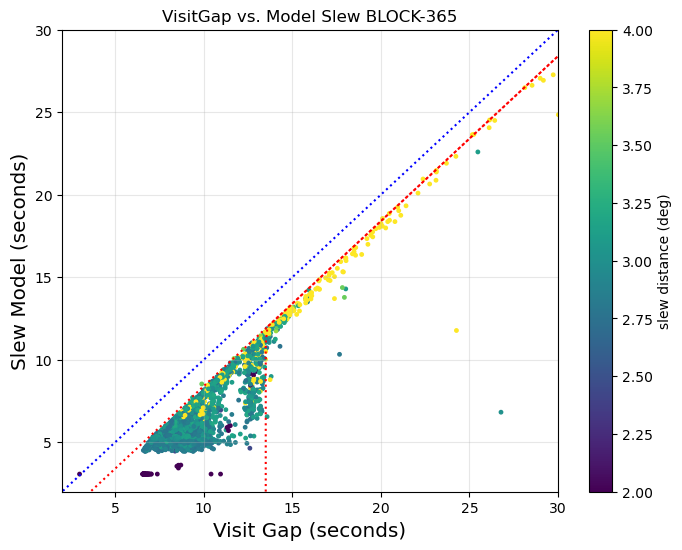

In [52]:
plt.figure(figsize=(8, 6))
# Pull up slews *within* a given science_program 
within_program = np.where(vts.iloc[:-1].science_program.values == vts.iloc[1:].science_program.values)[0]
q = vts.iloc[within_program + 1]

q = q.query("science_program == @program and observation_reason != 'field_survey_science' and observation_reason != 'block-t548' ")
print(len(q), q.observation_reason.unique())
plt.scatter(q.visit_gap, q.slew_model, 
            c=q.slew_distance, vmin=2, vmax=4,
            s=6)
plt.colorbar(label='slew distance (deg)')
x = np.arange(0, 100)
plt.plot(x, x, 'b:')
plt.plot(x+1.6, x, 'r:')
plt.plot(np.max([x+1.6, x*0 + 13.5], axis=0), x, 'r:')
plt.xlim(4, 20)
plt.ylim(4, 20)
plt.xlim(2, 30)
plt.ylim(2, 30)
#plt.xlabel("Visit gap (seconds)", fontsize='x-large')
plt.ylabel("Slew Model (seconds)", fontsize='x-large')
plt.xlabel("Visit Gap (seconds)", fontsize='x-large')
plt.grid(alpha=0.3)
plt.title(f"VisitGap vs. Model Slew {program}", fontsize='large')
#plt.title(f"TMAevent SLEW vs. visit gap (BLOCK-365)", fontsize='large')
plt.savefig('SlewModelVsVisitGap.pdf')


In [53]:
q.iloc[np.where(q.slew_model.values - q.TMAslew.values > 20)][['visit_id', 'slew_model', 'TMAslew', 'mt_slew_time', 'observation_reason', 'fwhm_eff']]

,visit_id,slew_model,TMAslew,mt_slew_time,observation_reason,fwhm_eff
108,2025070100175,149.724730,37.38511,158.039083,triplet_pairs_iz_33.0,1.421057
154,2025070100221,126.786472,7.478937,145.536788,triplet_pairs_iz_33.0,1.291278
286,2025070100353,120.378871,7.894227,140.828584,pairs_iz_33.0,1.399754
335,2025070100402,135.036165,29.634948,148.446480,template_blob_r_33.0,1.531297
367,2025070100434,219.389876,106.131857,224.964131,template_blob_z_33.0,1.399274
...,...,...,...,...,...,...
7078,2025070900732,120.541555,10.622349,132.026597,pairs_zy_33.0,1.367119
7085,2025070900739,121.278569,11.123128,131.554644,pairs_yy_33.0,1.498750
7105,2025070900759,124.700835,15.062352,131.077276,pairs_ri_33.0,1.526451
7120,2025070900774,119.456471,9.992794,130.693142,pairs_ri_33.0,1.487022


['triplet_pairs_iz_33.0' 'template_blob_z_33.0' 'pairs_iz_33.0'
 'template_blob_r_33.0' 'template_blob_i_33.0' 'pairs_ri_15.0'
 'ddf_elaiss1' 'pairs_gr_33.0' 'pairs_zy_33.0' 'template_blob_y_33.0'
 'pairs_yy_33.0' 'too' 'template_area_singles_i' 'singles_i'
 'pairs_ri_33.0' 'pairs_zy_15.0']


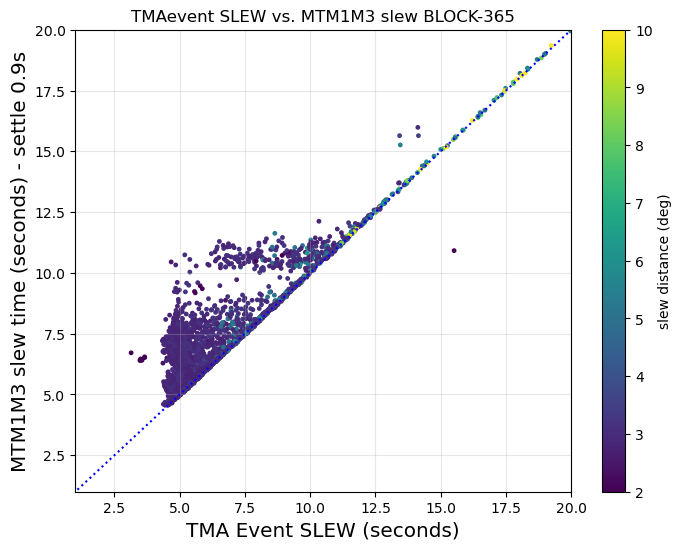

In [54]:
plt.figure(figsize=(8, 6))
# Pull up slews *within* a given science_program 
within_program = np.where(vts.iloc[:-1].science_program.values == vts.iloc[1:].science_program.values)[0]
q = vts.iloc[within_program + 1]

# not "field_survey_science" #"BLOCK-T548"
#q = q.query('science_program == @program')
q = q.query("science_program == @program and observation_reason != 'field_survey_science' and observation_reason != 'block-t548' and day_obs < 20260415")
print(q.observation_reason.unique())
settle = 0.9
plt.scatter(q.TMAslew, q.mt_slew_time - settle, 
            c= q.slew_distance, vmin=2, vmax=10,
            s=6)
plt.colorbar(label="slew distance (deg)")
x = np.arange(0, 100)
plt.plot(x, x, 'b:')
plt.xlim(1, 20)
plt.ylim(1, 20)
#plt.xlim(0, 200)
#plt.ylim(0, 200)
#plt.xlabel("Visit gap (seconds)", fontsize='x-large')
plt.ylabel(f"MTM1M3 slew time (seconds) - settle {settle}s", fontsize='x-large')
plt.xlabel("TMA Event SLEW (seconds)", fontsize='x-large')
plt.grid(alpha=0.3)
#plt.title(f"TMAevent SLEW vs. Model Slew {program}", fontsize='large')
plt.title(f"TMAevent SLEW vs. MTM1M3 slew {program}", fontsize='large')
plt.savefig('mtm1m3VsTMA.png')

['triplet_pairs_iz_33.0' 'template_blob_z_33.0' 'pairs_iz_33.0'
 'template_blob_r_33.0' 'template_blob_i_33.0' 'pairs_ri_15.0'
 'ddf_elaiss1' 'pairs_gr_33.0' 'pairs_zy_33.0' 'template_blob_y_33.0'
 'pairs_yy_33.0' 'too' 'template_area_singles_i' 'singles_i'
 'pairs_ri_33.0' 'pairs_zy_15.0']


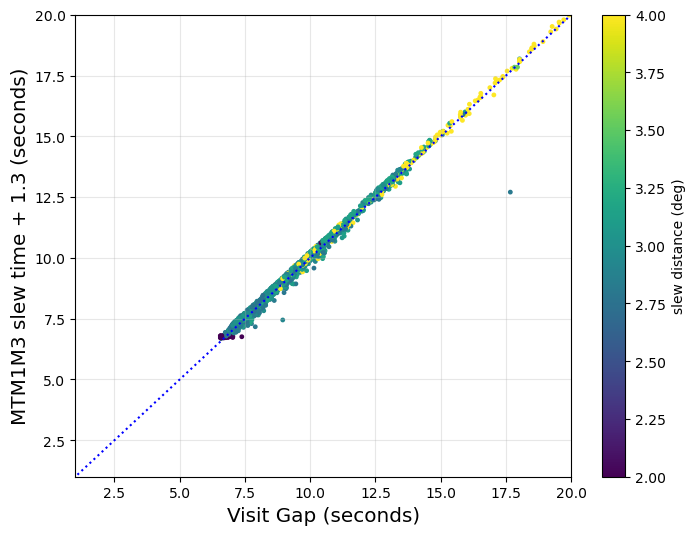

In [56]:
plt.figure(figsize=(8, 6))
# Pull up slews *within* a given science_program 
within_program = np.where(vts.iloc[:-1].science_program.values == vts.iloc[1:].science_program.values)[0]
q = vts.iloc[within_program + 1]
#q = q.query('science_program == @program and day_obs > 20260515')
q = q.query("science_program == @program and observation_reason != 'field_survey_science' and observation_reason != 'block-t548'")
#q = vts
print(q.observation_reason.unique())
extra = 1.3
plt.scatter(q.visit_gap, q.mt_slew_time + extra,# + q.waitBeforeSlew - 0.5,
            c= q.slew_distance, vmin=2, vmax=4,
            s=6)
plt.colorbar(label="slew distance (deg)")
x = np.arange(0, 100)
plt.plot(x, x, 'b:')
plt.xlim(1, 20)
plt.ylim(1, 20)
#plt.xlim(0, 50)
#plt.ylim(0, 50)
#plt.xlabel("Visit gap (seconds)", fontsize='x-large')
plt.ylabel(f"MTM1M3 slew time + {extra} (seconds)", 
           fontsize='x-large')
plt.xlabel("Visit Gap (seconds)", fontsize='x-large')
plt.grid(alpha=0.3)
#plt.title(f"TMAevent SLEW vs. Model Slew {program}", fontsize='large')
#plt.title(f"Visit gap vs. MTM1M3 slew (BLOCK-365)", fontsize='large')
plt.savefig('mtm1m3VsisitGap.png')

['triplet_pairs_iz_33.0' 'template_blob_z_33.0' 'pairs_iz_33.0'
 'template_blob_r_33.0' 'template_blob_i_33.0' 'pairs_ri_15.0'
 'ddf_elaiss1' 'pairs_gr_33.0' 'pairs_zy_33.0' 'template_blob_y_33.0'
 'pairs_yy_33.0' 'too' 'template_area_singles_i' 'singles_i'
 'pairs_ri_33.0' 'pairs_zy_15.0']


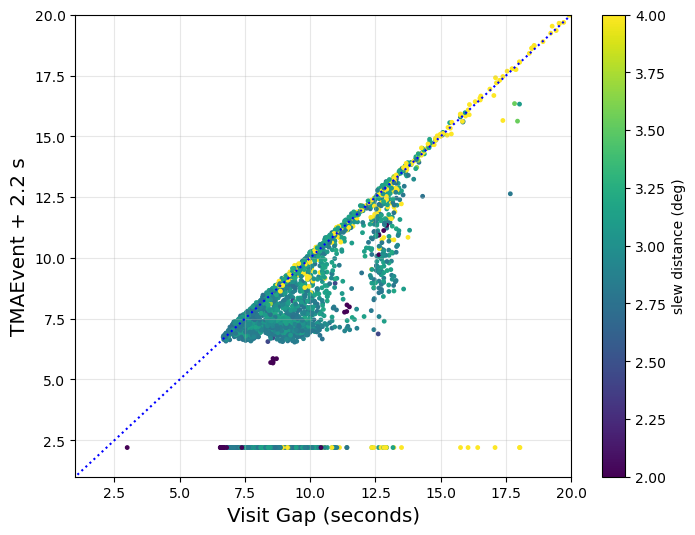

In [57]:
plt.figure(figsize=(8, 6))
# Pull up slews *within* a given science_program 
within_program = np.where(vts.iloc[:-1].science_program.values == vts.iloc[1:].science_program.values)[0]
q = vts.iloc[within_program + 1]
#q = q.query('science_program == @program and day_obs < 20260420')
#q = q.query('science_program == @program and day_obs > 20260515')
q = q.query("science_program == @program and observation_reason != 'field_survey_science' and observation_reason != 'block-t548'")
#q = vts
print(q.observation_reason.unique())
extra = 1.3 + 0.9
plt.scatter(q.visit_gap, q.TMAslew + extra,
            c= q.slew_distance, vmin=2, vmax=4,
            s=6)
plt.colorbar(label="slew distance (deg)")
x = np.arange(0, 100)
plt.plot(x, x, 'b:')
plt.xlim(1, 20)
plt.ylim(1, 20)
#plt.xlim(0, 50)
#plt.ylim(0, 50)
#plt.xlabel("Visit gap (seconds)", fontsize='x-large')
plt.ylabel(f"TMAEvent + {extra} s", 
           fontsize='x-large')
plt.xlabel("Visit Gap (seconds)", fontsize='x-large')
plt.grid(alpha=0.3)
#plt.title(f"TMAevent SLEW vs. Model Slew {program}", fontsize='large')
#plt.title(f"Visit gap vs. MTM1M3 slew (BLOCK-365)", fontsize='large')
plt.savefig('tmaEventvsVisitGap.png')

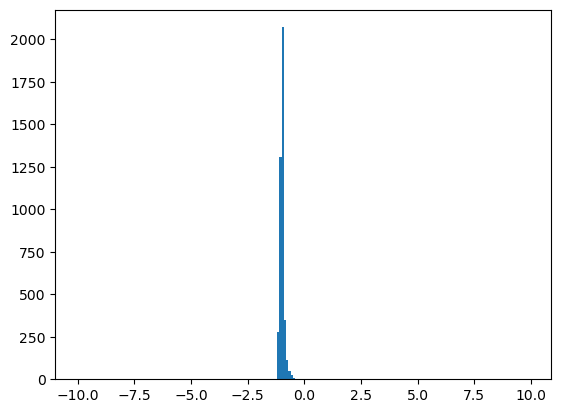

In [58]:
_= plt.hist(q.visit_gap - (q.mt_slew_time + extra), bins=np.arange(-10, 10, 0.1))

In [59]:
q.loc[q.slew_distance > 10].query("science_program == @program")[['visit_id', 'band', 's_ra', 's_dec', 'sky_rotation', 
                                                                                                    'altitude', 'azimuth', 
                                                                                                    'nTMAstops', 'waitBeforeSlew', 'waitAfterSlew', 'TMAslew', 'slew_model', 'mt_slew_time', 'slew_distance', 'observation_reason']]

,visit_id,band,s_ra,s_dec,sky_rotation,altitude,azimuth,nTMAstops,waitBeforeSlew,waitAfterSlew,TMAslew,slew_model,mt_slew_time,slew_distance,observation_reason
108,2025070100175,i,267.219945,-30.933335,127.022654,45.053256,104.976803,1,224.312437,15.819435,37.38511,149.724730,158.039083,34.554752,triplet_pairs_iz_33.0
238,2025070100305,z,266.279910,-16.411227,106.524343,61.574464,67.073638,0,1.469312,0.671136,35.817239,36.408907,36.723331,15.619592,pairs_iz_33.0
254,2025070100321,z,271.114112,-20.574736,115.425951,62.121922,76.577694,0,1.462595,0.679914,42.688371,43.765878,43.619734,18.154080,pairs_iz_33.0
302,2025070100369,i,271.114096,-20.574760,115.425433,70.325748,65.022552,0,1.468485,1.337568,62.811774,64.117017,63.746241,18.153754,pairs_iz_33.0
335,2025070100402,r,279.373844,-13.995271,90.618290,68.147428,45.355092,1,1.483389,17.570593,29.634948,135.036165,148.446480,10.099762,template_blob_r_33.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7041,2025070900695,r,342.044640,-1.972826,119.992311,61.529426,4.318360,1,1.485048,10.870341,15.299546,130.405729,133.226515,10.799696,template_blob_r_33.0
7042,2025070900696,r,320.288346,-22.461886,53.773300,70.352435,288.885095,0,1.444276,0.687684,76.969205,76.997887,77.919660,29.430667,template_blob_r_33.0
7045,2025070900699,r,15.163566,7.727758,155.670664,40.008858,45.882568,0,1.480568,0.662588,120.745714,121.498391,121.692086,59.873438,template_blob_r_33.0
7052,2025070900706,r,345.099779,-2.897816,125.756706,62.425434,5.179796,0,1.530385,0.654858,35.051521,35.736376,35.991115,32.635748,template_blob_r_33.0


visit_gap                         TMAslew            waitBeforeSlew  \
            median   mean   min      max    median       mean         median   
day_obs                                                                        
20250701      9.36  18.42  6.78  1176.18  6.436307   9.277951       1.474598   
20250702     10.13  28.82  6.86   811.85  6.817926  10.643615       1.491749   
20250703      9.13  18.76  6.89   566.47  6.024872   9.950843       1.485999   
20250704      9.05  13.47  6.78   391.30  5.770694   6.909764       1.476977   
20250706      8.57  17.95  6.67  1585.90  5.272051   6.838924       1.475332   
20250708      8.85  22.92  6.78  1900.62  5.606303   7.656217       1.501577   
20250709      9.10  16.63  6.75   767.48  6.084151   8.645998       1.489973   

                   waitAfterSlew           mt_slew_time  
              mean        median      mean       median  
day_obs                                                  
20250701   3.24585      0.756367  1.600212         8.10  
20250702  9.071305      0.858318  2.859812         8.63  
20250703    1.5337      0.808314   2.45734         7.87  
20250704  2.381853      0.911917  1.758759         7.83  
20250706  3.232998      0.975852  2.644738         7.31  
20250708  2.155321      0.900269  3.189297         7.60  
20250709  3.166276      0.710693   1.47932         8.01

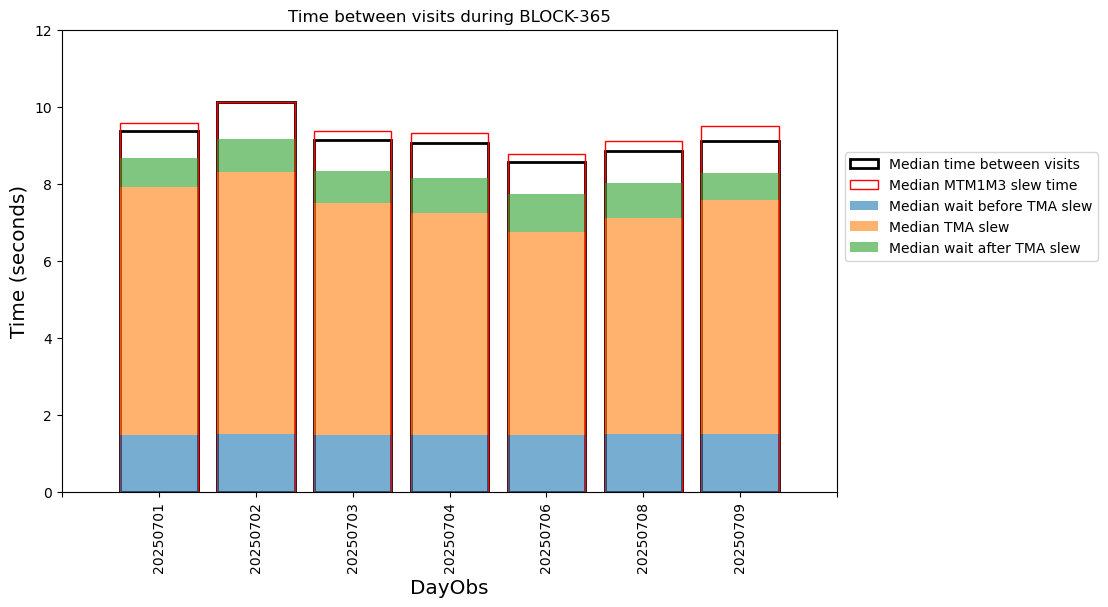

In [60]:
q = vts.iloc[within_program + 1]
q = q.query("science_program == @program and observation_reason != 'field_survey_science' and observation_reason != 'block-t548' and waitBeforeSlew < 3000")
dd = q.groupby('day_obs').agg({'visit_gap': ['median', 'mean', 'min', 'max'], 'TMAslew': ['median', 'mean'], 'waitBeforeSlew': ['median', 'mean'], 'waitAfterSlew': ['median', 'mean'], 'mt_slew_time' : ['median']})
display(dd.round(2))

x = np.arange(0, len(dd))
plt.figure(figsize=(10, 6))
plt.bar(x, dd['visit_gap', 'median'], edgecolor='k', facecolor='none', linewidth=2, label='Median time between visits')
plt.bar(x, dd['mt_slew_time', 'median'] + dd['waitBeforeSlew', 'median'], edgecolor='r', facecolor='none', linewidth=1, label="Median MTM1M3 slew time")

y = dd['waitBeforeSlew', 'median']
plt.bar(x, y, alpha=0.6, edgecolor=None, label="Median wait before TMA slew")
ys = dd['TMAslew', 'median']
plt.bar(x, ys, bottom=y, alpha=0.6, edgecolor=None, label="Median TMA slew")
ya = dd['waitAfterSlew', 'median']
plt.bar(x, ya, bottom=y + ys, alpha=0.6, edgecolor=None, label="Median wait after TMA slew")
_ = plt.xticks(ticks=x, labels=dd.index, rotation=90)
plt.xlim(-1, len(dd))
plt.ylim(0, 12)
ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(1)) 
plt.legend(loc=(1.01, 0.5))
plt.xlabel("DayObs", fontsize='x-large')
plt.ylabel("Time (seconds)", fontsize='x-large')
plt.title(f"Time between visits during {program}", fontsize='large')
plt.savefig('TimeBetweenVisits.png')

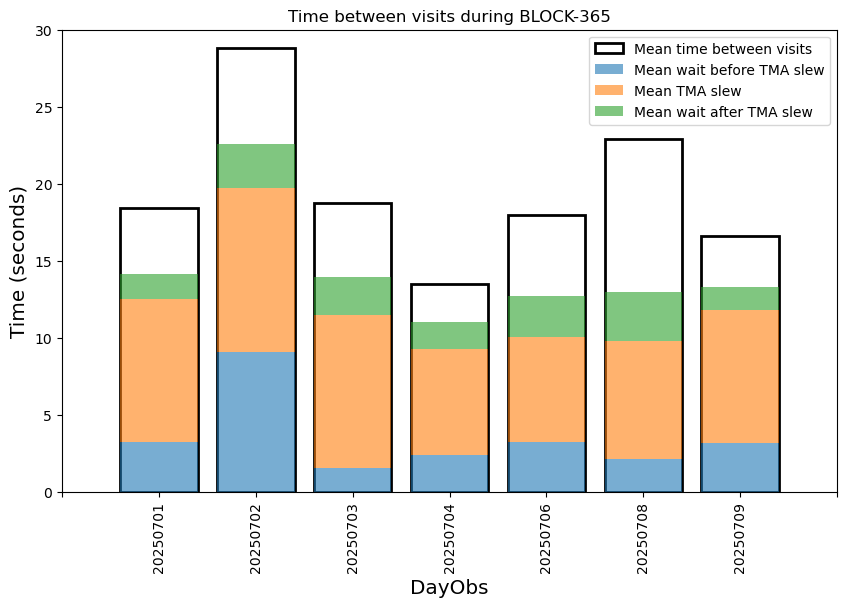

In [63]:
dd = q.groupby('day_obs').agg({'visit_gap': ['median', 'mean', 'min', 'max'], 'exp_midpt': 'first', 'TMAslew': ['median', 'mean'], 'waitBeforeSlew': ['median', 'mean'], 'waitAfterSlew': ['median', 'mean']})

x = np.arange(0, len(dd))
plt.figure(figsize=(10, 6))
plt.bar(x, dd['visit_gap', 'mean'], edgecolor='k', facecolor='white', linewidth=2, label='Mean time between visits')

y = dd['waitBeforeSlew', 'mean']
plt.bar(x, y, alpha=0.6, edgecolor=None, label="Mean wait before TMA slew")
ys = dd['TMAslew', 'mean']
plt.bar(x, ys, bottom=y, alpha=0.6, edgecolor=None, label="Mean TMA slew")
ya = dd['waitAfterSlew', 'mean']
plt.bar(x, ya, bottom=y + ys, alpha=0.6, edgecolor=None, label="Mean wait after TMA slew")
_ = plt.xticks(ticks=x, labels=dd.index, rotation=90)
plt.xlim(-1, len(dd))
plt.ylim(0, 30)
ax = plt.gca()
ax.xaxis.set_major_locator(ticker.MultipleLocator(1)) 
plt.legend()
plt.xlabel("DayObs", fontsize='x-large')
plt.ylabel("Time (seconds)", fontsize='x-large')
plt.title(f"Time between visits during {program}", fontsize='large')
plt.savefig('TimeBetweenVisits.png')